In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import math
from torch.utils.data import DataLoader

from scipy.stats import norm


# Set random seed for reproducibility
np.random.seed(1)
torch.manual_seed(1)

batch_size=128
# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
mnist_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
data_loader = DataLoader(mnist_data, batch_size=batch_size , shuffle=True)

# Function to generate y values
def generate_y(t, is_even):
     
    if is_even:        
        if t <0 :
         return  np.random.normal(0, 2)
        else :
            return np.zeros_like(t)
    else:
        if t>0:
            return np.random.normal(0, 2)
        else :
            return  np.zeros_like(t)
        
def autoselect_scales_mix_norm(betahat, sebetahat, max_class=None, mult=2):
    betahat = np.asarray(betahat)
    sebetahat = np.asarray(sebetahat)

    # lower scale bound
    sigmaamin = float(np.min(sebetahat)) / 10.0

    # upper scale bound (handle negative under sqrt)
    if np.all(betahat**2 < sebetahat**2):
        sigmaamax = 8.0 * sigmaamin
    else:
        sigmaamax = 2.0 * float(np.sqrt(np.maximum(0.0, np.max(betahat**2 - sebetahat**2))))

    # ensure sigmaamax >= sigmaamin * mult (avoid degenerate grid)
    sigmaamax = max(sigmaamax, sigmaamin * (mult if mult and mult > 1 else 2.0))

    if not mult or mult <= 1:
        # fallback: just two points [0, mid]
        out = np.array([0.0, (sigmaamin + sigmaamax) / 2.0], dtype=float)
    else:
        ratio = sigmaamax / sigmaamin
        npoint = int(math.ceil(math.log(ratio) / math.log(mult)))
        npoint = max(npoint, 1)
        sequence = np.arange(-npoint, 1)
        out = np.concatenate(([0.0], (1.0 / mult) ** (-sequence) * sigmaamax)).astype(float)

    if max_class is not None:
        # keep the spike at 0, resample the positive scales to fill remaining slots
        if max_class < 2:
            out = np.array([0.0], dtype=float)
        else:
            pos = out[1:]
            if pos.size == 0:
                pos = np.array([sigmaamax], dtype=float)
            pos_resamp = np.linspace(pos.min(), pos.max(), num=max_class - 1)
            out = np.concatenate(([0.0], pos_resamp)).astype(float)

    return out

        
def get_data_loglik_normal(betahat, sebetahat, location, scale):
    # betahat, sebetahat: 1D arrays of length N
    # location: scalar, or shape (M,), or shape (N, M)
    # scale: 1D array of length M
    betahat = np.asarray(betahat).reshape(-1)
    sebetahat = np.asarray(sebetahat).reshape(-1)
    scale = np.asarray(scale).reshape(-1)

    N = betahat.shape[0]
    M = scale.shape[0]
    out = np.zeros((N, M), dtype=float)

    if np.isscalar(location):
        # same location for all rows
        for i in range(N):
            out[i, :] = convolved_logpdf_normal(
                betahat=betahat[i],
                sebetahat=sebetahat[i],
                location=location,
                scale=scale
            )
    else:
        location = np.asarray(location)
        if location.ndim == 1:
            if location.shape[0] != M:
                raise ValueError("location length must match scale length when 1D.")
            for i in range(N):
                out[i, :] = convolved_logpdf_normal(
                    betahat=betahat[i],
                    sebetahat=sebetahat[i],
                    location=location,
                    scale=scale
                )
        elif location.ndim == 2:
            if location.shape != (N, M):
                raise ValueError("location must be (N, M) if 2D.")
            for i in range(N):
                out[i, :] = convolved_logpdf_normal(
                    betahat=betahat[i],
                    sebetahat=sebetahat[i],
                    location=location[i, :],
                    scale=scale
                )
        else:
            raise ValueError("location must be scalar, 1D, or 2D.")
    return out

def convolved_logpdf_normal(betahat, sebetahat, location, scale):
    # betahat, sebetahat are scalars for one observation
    # location: 1D array (same length as scale) or scalar
    # scale: 1D array of prior stds
    betahat = float(betahat)
    sebetahat = float(sebetahat)
    scale = np.asarray(scale)

    if np.isscalar(location):
        loc = float(location)
        loc_vec = np.full_like(scale, loc, dtype=float)
    else:
        loc_vec = np.asarray(location, dtype=float)
        if loc_vec.shape != scale.shape:
            raise ValueError("location and scale must have the same shape, or location must be scalar.")

    sd = np.sqrt(sebetahat**2 + scale**2)
    logp = norm.logpdf(betahat, loc=loc_vec, scale=sd)
    return np.clip(logp, -1e5, 1e5)
 
# Custom Dataset class to handle MNIST images and simulated data
class SimulatedMNISTDataset(Dataset):
    def __init__(self, mnist_data, positions, y_values, y_noisy, digits, noise_level, label_type, image_label):
        self.image = mnist_data 
        self.mnist_data = mnist_data
        self.positions = torch.tensor(positions, dtype=torch.float32)
        self.y_values = torch.tensor(y_values, dtype=torch.float32)
        self.y_noisy = torch.tensor(y_noisy, dtype=torch.float32)
        self.digits = torch.tensor(digits, dtype=torch.long)
        self.noise_level = noise_level
        self.label_type = label_type
        self.image_label=image_label
        self.scale = autoselect_scales_mix_norm(
            betahat=np.array(self.y_noisy),
            sebetahat=np.array(self.noise_level)
        )
        
        self.Lim =torch.tensor(  get_data_loglik_normal(
            betahat=np.array(self.y_noisy),
            sebetahat=np.array(self.noise_level),
            location=0,
            scale=self.scale
                     ) , dtype=torch.float32)

    def __len__(self):
        return len(self.mnist_data)

    
    def __getitem__(self, idx):
        image, _ = self.mnist_data[idx]
        position = self.positions[idx]
        y_value = self.y_values[idx]
        y_noisy = self.y_noisy[idx]
        digit = self.digits[idx]
        marginal_log_lik = self.Lim[idx]
        
        return image, digit, position, y_value, y_noisy, marginal_log_lik

In [2]:
# Generate the simulated dataset
n_samples = 50000
noise_level = 1
positions = []
y_values = []
digits = []
y_noisy = []
label_type= []
image_label =[]
# Ensure unique indices are used
unique_indices = np.random.choice(len(mnist_data), size=n_samples, replace=False)
filtered_mnist_data = torch.utils.data.Subset(mnist_data, unique_indices)

# Run simulation to generate noisy data
for idx in unique_indices:
    image, label = mnist_data[idx]
    t = np.random.uniform(-0.5, 0.5)
    is_even = label % 2 == 0
    y = generate_y(t, is_even)
    noise = np.random.normal(0, noise_level)
    y_noisy_value = y + noise
    positions.append(t)
    y_values.append(y)
    y_noisy.append(y_noisy_value)
    digits.append(label)
    image_label.append(label)
    label_type.append(is_even)
    
positions = np.array(positions)
y_values = np.array(y_values)
y_noisy = np.array(y_noisy)
digits = np.array(digits)
label_type = np.array(label_type)
image_label = np.array(image_label)
noiseless=y_values
# Create custom dataset with the filtered MNIST dataset and simulated data
simulated_dataset = SimulatedMNISTDataset(
    mnist_data=filtered_mnist_data,
    positions=positions,
    y_values=y_values,
    y_noisy=y_noisy,
    digits=digits,
    noise_level=np.repeat(1, y_noisy.shape[0]),
    label_type=label_type,
    image_label =image_label
)

/var/folders/bs/p8m_n1pj5xq_f1p787_22x6c0000gn/T/ipykernel_8661/4028930349.py:161: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  betahat=np.array(self.y_noisy),
/var/folders/bs/p8m_n1pj5xq_f1p787_22x6c0000gn/T/ipykernel_8661/4028930349.py:166: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  betahat=np.array(self.y_noisy),


In [4]:
# 1) Collect everything first (as before)
train_loader = DataLoader(simulated_dataset, batch_size=batch_size , shuffle=True)

all_data = []
all_digit = []
all_pos = []
all_y_value = []
all_y_noisy = []
all_marginal_log_lik = []

for batch_idx, (data, digit, pos, y_value, y_noisy, marginal_log_lik) in enumerate(train_loader):
    all_data.append(data)
    all_digit.append(digit)
    all_pos.append(pos)
    all_y_value.append(y_value)
    all_y_noisy.append(y_noisy)
    all_marginal_log_lik.append(marginal_log_lik)

# 2) Concatenate along batch dimension
all_data = torch.cat(all_data, dim=0)              # shape (N, C, H, W)
all_digit = torch.cat(all_digit, dim=0)
all_pos = torch.cat(all_pos, dim=0)                # shape (N, P)
all_y_value = torch.cat(all_y_value, dim=0)
all_y_noisy = torch.cat(all_y_noisy, dim=0)
all_marginal_log_lik = torch.cat(all_marginal_log_lik, dim=0)

# 3) Flatten images to vectors
all_data_flat = all_data.view(all_data.size(0), -1)   # shape (N, C*H*W)

# 4) Concatenate flattened images with pos features
inputs = torch.cat([all_data_flat, all_pos.unsqueeze(1)], dim=1)   # shape (N, C*H*W + P)

print("Final input shape:", inputs.shape)


import torch

# Suppose we stack noisy observations as a column vector L
L = torch.tensor(all_y_noisy, dtype=torch.float32).unsqueeze(1)  # shape (n_samples, 1)

L_true = torch.tensor(all_y_value, dtype=torch.float32).unsqueeze(1)  # shape (n_samples, 1)

# Choose number of latent factors (rank)
K = 10  

# Generate F as Gaussian random draws

F = torch.randn((K, L.shape[1]))  # shape (K, 1)

# Approximate data matrix
Y_hat = L @ F.T # shape (n_samples, K)

Y_true = L_true @F.T

Y_noisy = Y_hat #+ torch.randn((Y_hat.shape))

print("L shape:", L.shape)
print("F shape:", F.shape)
print("Y_hat shape:", Y_hat.shape)
print("Y_noisy shape:", Y_noisy.shape)

Final input shape: torch.Size([50000, 785])
L shape: torch.Size([50000, 1])
F shape: torch.Size([10, 1])
Y_hat shape: torch.Size([50000, 10])
Y_noisy shape: torch.Size([50000, 10])


/var/folders/bs/p8m_n1pj5xq_f1p787_22x6c0000gn/T/ipykernel_8661/3776199935.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L = torch.tensor(all_y_noisy, dtype=torch.float32).unsqueeze(1)  # shape (n_samples, 1)
/var/folders/bs/p8m_n1pj5xq_f1p787_22x6c0000gn/T/ipykernel_8661/3776199935.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L_true = torch.tensor(all_y_value, dtype=torch.float32).unsqueeze(1)  # shape (n_samples, 1)


reg strength: 0.0001
[EMDN] Epoch 10/50, Loss: 2.7602
[EMDN] Epoch 20/50, Loss: 2.6721
[EMDN] Epoch 30/50, Loss: 2.5278
[EMDN] Epoch 40/50, Loss: 2.4659
[EMDN] Epoch 50/50, Loss: 2.4247


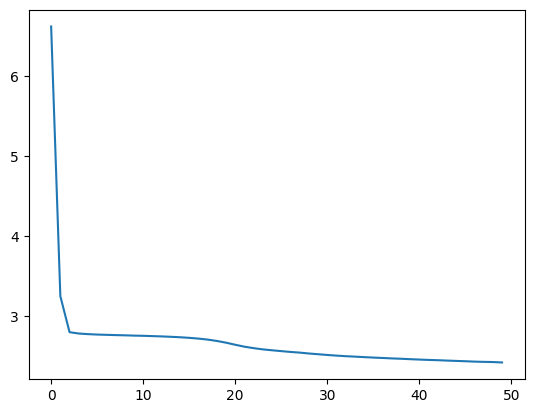

reg strength: 0.0001
[EMDN] Epoch 10/50, Loss: -4.1737
[EMDN] Epoch 20/50, Loss: -4.2961
[EMDN] Epoch 30/50, Loss: -4.4432
[EMDN] Epoch 40/50, Loss: -4.7683
[EMDN] Epoch 50/50, Loss: -4.1506


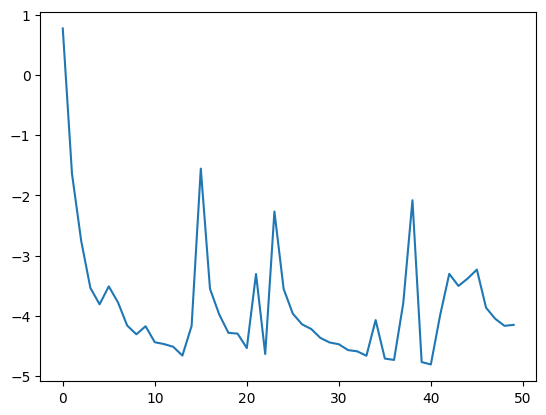

reg strength: 0.0001
[EMDN] Epoch 10/50, Loss: -4.1876
[EMDN] Epoch 20/50, Loss: -4.3060
[EMDN] Epoch 30/50, Loss: -4.7252
[EMDN] Epoch 40/50, Loss: -4.6489
[EMDN] Epoch 50/50, Loss: -4.8686


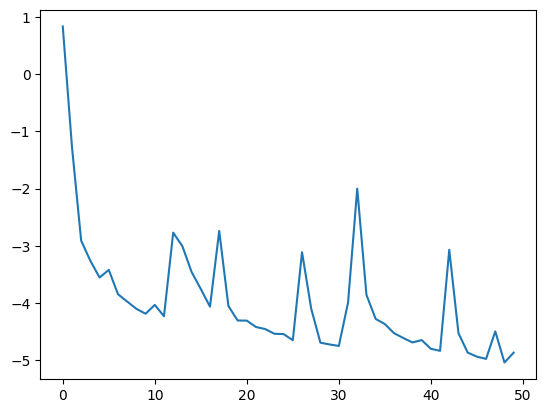

reg strength: 0.0001
[EMDN] Epoch 10/50, Loss: 2.7612
[EMDN] Epoch 20/50, Loss: 1.7916
[EMDN] Epoch 30/50, Loss: -0.1049
[EMDN] Epoch 40/50, Loss: -0.4188
[EMDN] Epoch 50/50, Loss: -0.5987


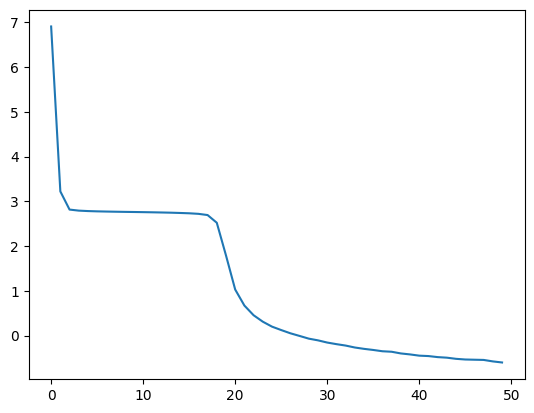

reg strength: 0.0001
[EMDN] Epoch 10/50, Loss: -4.4057
[EMDN] Epoch 20/50, Loss: -4.7635
[EMDN] Epoch 30/50, Loss: -3.9273
[EMDN] Epoch 40/50, Loss: -4.6706
[EMDN] Epoch 50/50, Loss: -1.7945


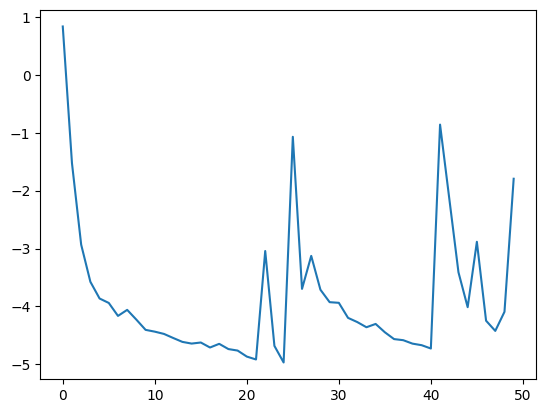

Converged after 19 iterations.
reg strength: 0.0001
[EMDN] Epoch 10/50, Loss: -4.0436
[EMDN] Epoch 20/50, Loss: -4.0451
[EMDN] Epoch 30/50, Loss: -3.7823
[EMDN] Epoch 40/50, Loss: -3.8220
[EMDN] Epoch 50/50, Loss: -5.0668


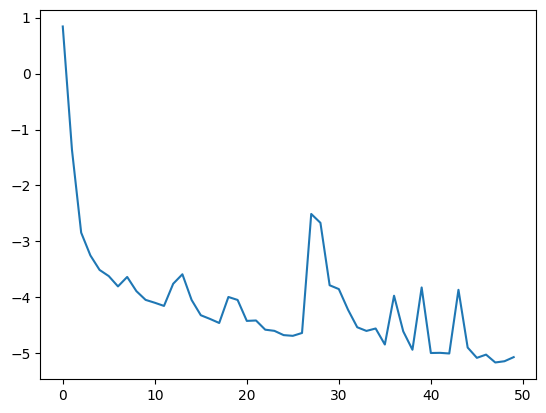

Converged after 19 iterations.


In [9]:
import torch
from cebmf_torch import cEBMF
from cebmf_torch.torch_main import ModelParams, NoiseParams, CovariateParams

#from cebmf_torch.models import cEBMF, ModelParams

model_params = ModelParams(prior_L="emdn", prior_F="norm", K=3)

#model_params_unlearned = ModelParams(prior_L="norm", prior_F="norm", K=3)

covars = CovariateParams(X_l = inputs, X_f = torch.ones(Y_noisy.shape[1]), self_row_cov = True, self_col_cov = False)

cebmf_model = cEBMF(data=Y_noisy, model=model_params, covariate = covars)
cebmf_model_unlearned = cEBMF(data=Y_noisy)

# Fit
fit = cebmf_model.fit(maxit=2)
#fit_unlearned = cebmf_model_unlearned.fit(maxit=2)

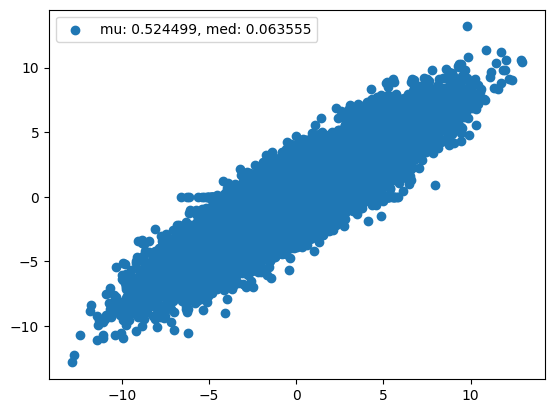

In [6]:
A_prime = (fit.L @ fit.F.T)
mse = (Y_true - A_prime)**2

plt.scatter(A_prime.numpy().flatten()[:], Y_true.numpy().flatten()[:], label = f'mu: {torch.mean(mse):.6f}, med: {torch.median(mse):.6f}')

#A_prime_unlearned = (fit_unlearned.L @ fit_unlearned.F.T)
#mse_unlearned = (Y_true - A_prime_unlearned)**2
#plt.scatter(A_prime_unlearned.numpy().flatten(), Y_true.numpy().flatten(), label = f'mu: {torch.mean(mse_unlearned):.6f}, med: {torch.median(mse_unlearned):.6f}')
plt.legend()
plt.show()

In [7]:
fit_unlearned = cebmf_model_unlearned.fit(maxit=2)

Converged after 19 iterations.
Converged after 19 iterations.
Converged after 19 iterations.
Converged after 19 iterations.


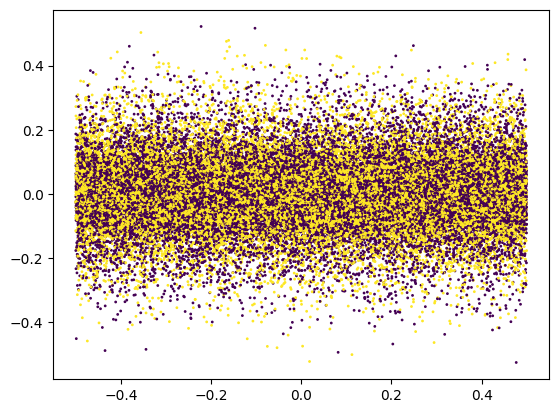

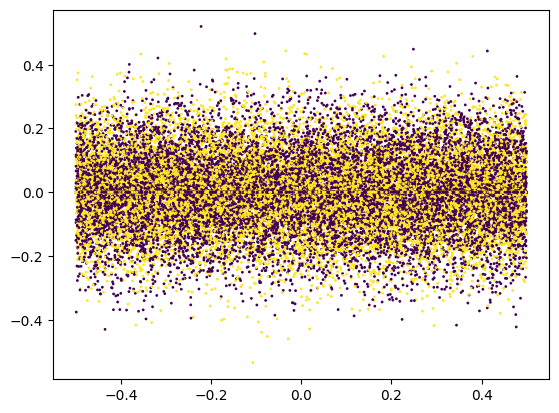

In [11]:
all_even = digits % 2 == 0
plt.scatter(all_pos, A_prime.T[0], c = all_even, s= 1)
plt.show()
plt.scatter(all_pos, Y_true.T[0], c = all_even, s= 1)

plt.show()

### CLIP Embeddings for large images

In [31]:
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

# Load pretrained CLIP
device = "mps" if torch.mps.is_available() else "cpu"
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def get_clip_embedding_old(image_path_or_pil):
    """
    Takes a file path or PIL.Image, returns a 512-dim CLIP embedding.
    Works for any input image size.
    """
    if isinstance(image_path_or_pil, str):
        image = Image.open(image_path_or_pil).convert("RGB")
    else:
        image = image_path_or_pil  # already PIL.Image
    
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        image_emb = model.get_image_features(**inputs)
        image_emb = image_emb / image_emb.norm(p=2, dim=-1, keepdim=True)  # normalize
    
    return image_emb.squeeze(0)  # shape: (512,)



def get_clip_embedding(image_path_or_pil):
    """
    Takes a file path, PIL.Image, or single-channel tensor, returns a 512-dim CLIP embedding.
    Automatically converts grayscale images to RGB. Works for any input image size.
    """
    # Load image if path is provided
    if isinstance(image_path_or_pil, str):
        image = Image.open(image_path_or_pil)
    else:
        image = image_path_or_pil

    # If input is a torch tensor, convert to PIL
    if isinstance(image, torch.Tensor):
        if image.ndim == 3:  # [C,H,W]
            if image.shape[0] == 1:  # grayscale
                image = Image.fromarray((image[0].numpy() * 255).astype("uint8")).convert("RGB")
            elif image.shape[0] == 3:  # already RGB
                image = Image.fromarray((image.permute(1, 2, 0).numpy() * 255).astype("uint8"))
            else:
                raise ValueError(f"Unexpected number of channels: {image.shape[0]}")
        else:
            raise ValueError(f"Expected 3D tensor [C,H,W], got {image.ndim}D")
    
    # If image is grayscale PIL.Image, convert to RGB
    if image.mode != "RGB":
        image = image.convert("RGB")

    # Process and get embedding
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        image_emb = model.get_image_features(**inputs)
        image_emb = image_emb / image_emb.norm(p=2, dim=-1, keepdim=True)  # normalize
    
    return image_emb.squeeze(0)  # shape: (512,)

/Users/thomasmonahan/Documents/GitHub/cebmf_torch/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Fetching 1 files: 100%|████████████████████████| 1/1 [00:00<00:00, 16320.25it/s]


In [ ]:
import numpy as np

imagepaths = os.listdir('./your_image_folder')

all_embeddings = []
for img_path in image_paths:  # however you store them
    emb = get_clip_embedding(img_path).cpu().numpy()
    all_embeddings.append(emb)

all_embeddings = torch.torch(all_embeddings)  # shape (N, 512)

In [35]:
# Generate the simulated dataset
import tqdm
from tqdm import tqdm
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import math
from torch.utils.data import DataLoader

from scipy.stats import norm


# Set random seed for reproducibility
np.random.seed(1)
torch.manual_seed(1)

batch_size=128
# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
mnist_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
data_loader = DataLoader(mnist_data, batch_size=batch_size , shuffle=True)


n_samples = 25000
noise_level = 1
positions = []
y_values = []
digits = []
y_noisy = []
label_type= []
image_label =[]
embedded_images = []
flattened_images = []
# Ensure unique indices are used
unique_indices = np.random.choice(len(mnist_data), size=n_samples, replace=False)
filtered_mnist_data = torch.utils.data.Subset(mnist_data, unique_indices)

# Run simulation to generate noisy data
for idx in tqdm(unique_indices):
    image, label = mnist_data[idx]
    t = np.random.uniform(-0.5, 0.5)
    is_even = label % 2 == 0
    y = generate_y(t, is_even)
    noise = np.random.normal(0, noise_level)
    y_noisy_value = y + noise
    positions.append(t)
    y_values.append(float(y))
    y_noisy.append(y_noisy_value)
    digits.append(label)
    image_label.append(label)
    label_type.append(is_even)
    embedded_images.append(get_clip_embedding(image).cpu())
    flattened_images.append(image)

positions = torch.tensor(positions)
y_values = torch.tensor(y_values)
y_noisy = torch.tensor(y_noisy)
digits = torch.tensor(digits)
image_label = torch.tensor(image_label)
label_type = torch.tensor(label_type)
y_noisy_value = torch.tensor(y_noisy_value)
embedded_images = torch.stack(embedded_images)
flattened_images = torch.stack(flattened_images)
flattened_images = flattened_images.view(flattened_images.size(0), -1)

100%|████████████████████████████████████| 25000/25000 [03:46<00:00, 110.25it/s]


In [37]:
# Save all tensors to a single file
import torch

torch.save({
    "positions": positions,
    "y_values": y_values,
    "y_noisy": y_noisy,
    "digits": digits,
    "image_label": image_label,
    "label_type": label_type,
    "embedded_images": embedded_images,
    "flattened_images": flattened_images
}, "simulated_dataset.pt")

/var/folders/bs/p8m_n1pj5xq_f1p787_22x6c0000gn/T/ipykernel_13561/2752740099.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L = torch.tensor(y_noisy, dtype=torch.float32).unsqueeze(1)  # shape (n_samples, 1)
/var/folders/bs/p8m_n1pj5xq_f1p787_22x6c0000gn/T/ipykernel_13561/2752740099.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L_true = torch.tensor(y_values, dtype=torch.float32).unsqueeze(1)  # shape (n_samples, 1)


L shape: torch.Size([5000, 1])
F shape: torch.Size([1000, 1])
Y_hat shape: torch.Size([5000, 1000])
Y_noisy shape: torch.Size([5000, 1000])
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 201.9777
[EMDN] Epoch 20/50, Loss: 5.7920
[EMDN] Epoch 30/50, Loss: 5.5108
[EMDN] Epoch 40/50, Loss: 5.4190
[EMDN] Epoch 50/50, Loss: 5.3812


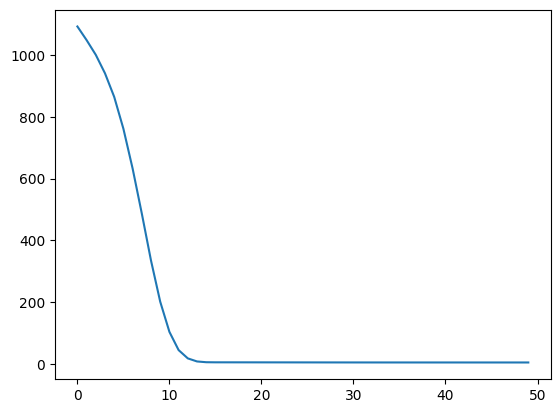

[update L0] post_mean mean=-1.0349, std=54.2100, min=-231.7874, max=234.2376
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 0.3181
[EMDN] Epoch 20/50, Loss: -1.9673
[EMDN] Epoch 30/50, Loss: -2.4944
[EMDN] Epoch 40/50, Loss: -2.6419
[EMDN] Epoch 50/50, Loss: -2.5050


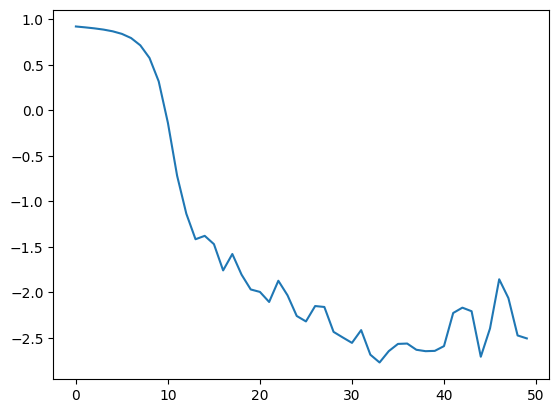

[update L1] post_mean mean=0.0000, std=0.0000, min=-0.0000, max=0.0000
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: -0.0901
[EMDN] Epoch 20/50, Loss: -1.7174
[EMDN] Epoch 30/50, Loss: -2.1567
[EMDN] Epoch 40/50, Loss: -2.0781
[EMDN] Epoch 50/50, Loss: -2.6411


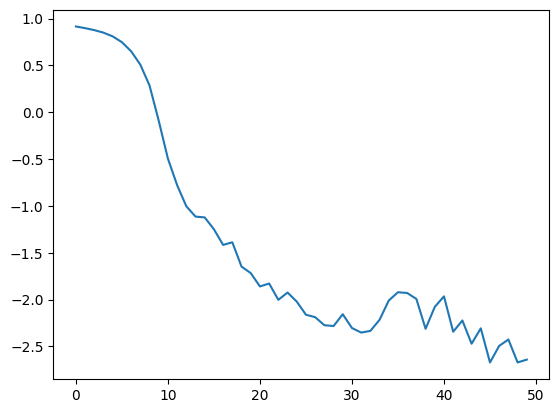

[update L2] post_mean mean=0.0000, std=0.0000, min=-0.0000, max=0.0000
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 225.2428
[EMDN] Epoch 20/50, Loss: 5.7284
[EMDN] Epoch 30/50, Loss: 5.5361
[EMDN] Epoch 40/50, Loss: 5.4709
[EMDN] Epoch 50/50, Loss: 5.4217


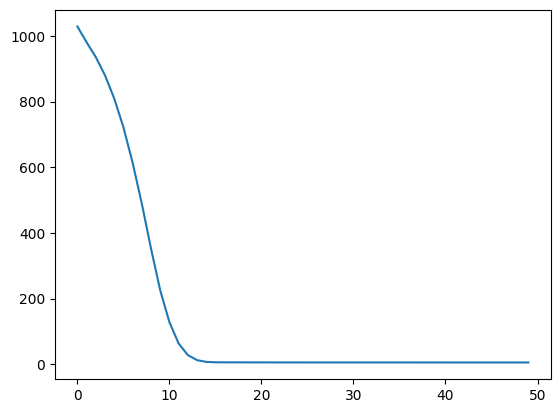

[update L0] post_mean mean=-1.0349, std=54.2100, min=-231.7873, max=234.2376
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 0.3814
[EMDN] Epoch 20/50, Loss: -2.0685
[EMDN] Epoch 30/50, Loss: -2.4399
[EMDN] Epoch 40/50, Loss: -1.9675
[EMDN] Epoch 50/50, Loss: -2.3392


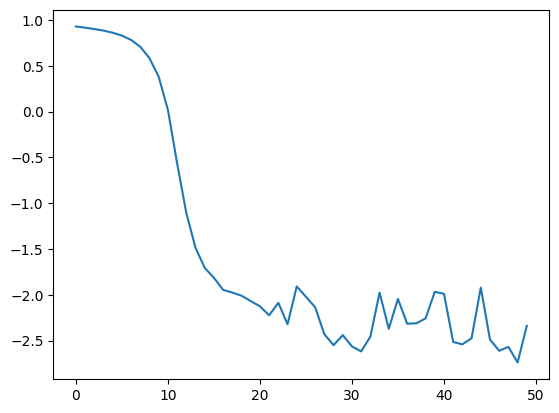

[update L1] post_mean mean=0.0000, std=0.0000, min=-0.0000, max=0.0000
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 0.1901
[EMDN] Epoch 20/50, Loss: -1.8806
[EMDN] Epoch 30/50, Loss: -2.2183
[EMDN] Epoch 40/50, Loss: -2.3651
[EMDN] Epoch 50/50, Loss: -2.7033


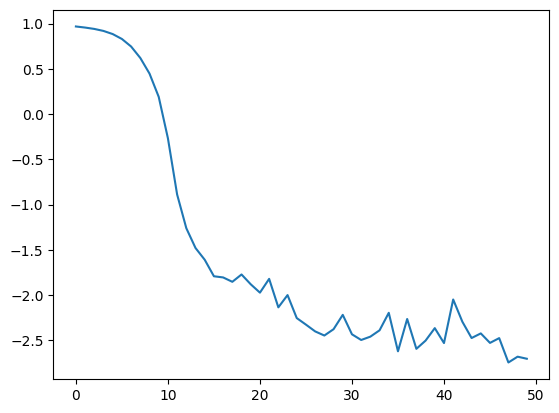

[update L2] post_mean mean=0.0000, std=0.0000, min=-0.0000, max=0.0000
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 551.1406
[EMDN] Epoch 20/50, Loss: 5.6339
[EMDN] Epoch 30/50, Loss: 5.4763
[EMDN] Epoch 40/50, Loss: 5.4023
[EMDN] Epoch 50/50, Loss: 5.3418


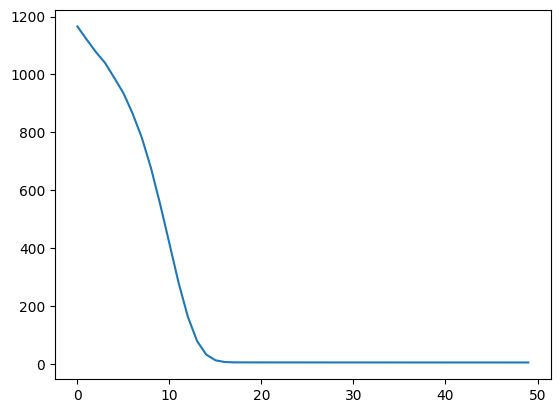

[update L0] post_mean mean=-1.0349, std=54.2100, min=-231.7875, max=234.2375
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 0.5610
[EMDN] Epoch 20/50, Loss: -1.6744
[EMDN] Epoch 30/50, Loss: -2.3128
[EMDN] Epoch 40/50, Loss: -2.7034
[EMDN] Epoch 50/50, Loss: -2.5118


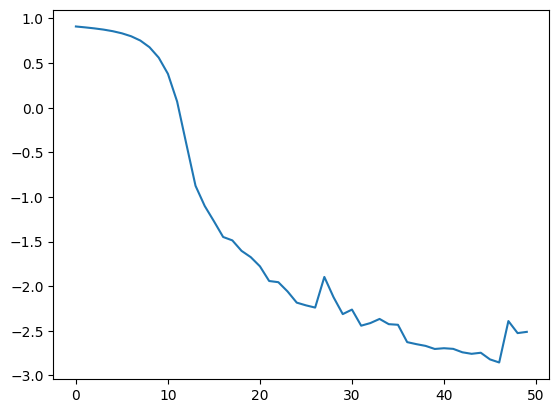

[update L1] post_mean mean=0.0000, std=0.0000, min=-0.0000, max=0.0000
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 0.1891
[EMDN] Epoch 20/50, Loss: -2.4479
[EMDN] Epoch 30/50, Loss: -2.8532
[EMDN] Epoch 40/50, Loss: -2.9045
[EMDN] Epoch 50/50, Loss: -3.1941


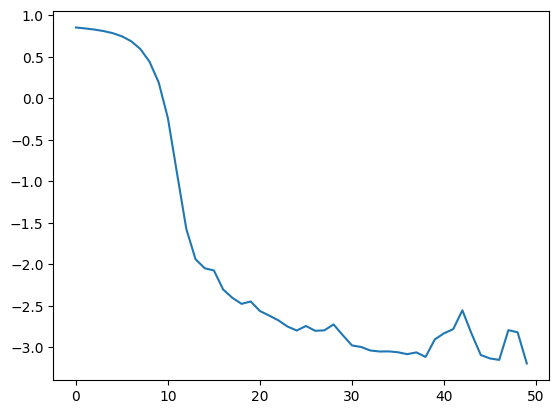

[update L2] post_mean mean=0.0000, std=0.0000, min=-0.0000, max=0.0000
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 344.8840
[EMDN] Epoch 20/50, Loss: 5.5580
[EMDN] Epoch 30/50, Loss: 5.4205
[EMDN] Epoch 40/50, Loss: 5.3529
[EMDN] Epoch 50/50, Loss: 5.2999


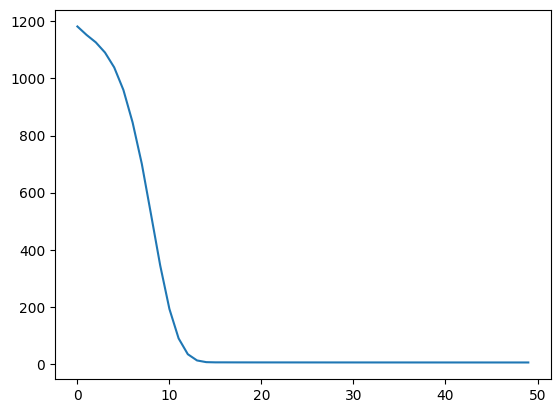

[update L0] post_mean mean=-1.0349, std=54.2100, min=-231.7874, max=234.2376
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 0.5903
[EMDN] Epoch 20/50, Loss: -1.7151
[EMDN] Epoch 30/50, Loss: -2.2524
[EMDN] Epoch 40/50, Loss: -1.9400
[EMDN] Epoch 50/50, Loss: -2.5369


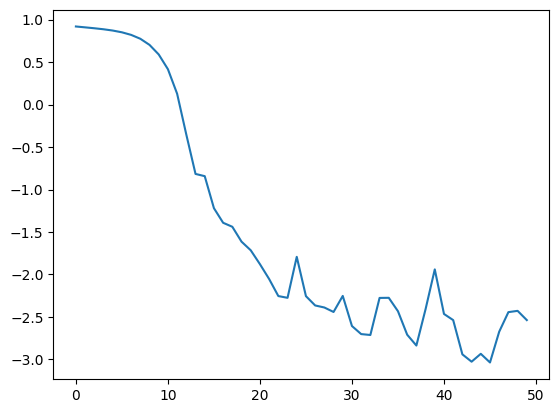

[update L1] post_mean mean=0.0000, std=0.0000, min=-0.0000, max=0.0000
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 0.1860
[EMDN] Epoch 20/50, Loss: -1.6252
[EMDN] Epoch 30/50, Loss: -2.2077
[EMDN] Epoch 40/50, Loss: -2.3831
[EMDN] Epoch 50/50, Loss: -2.2273


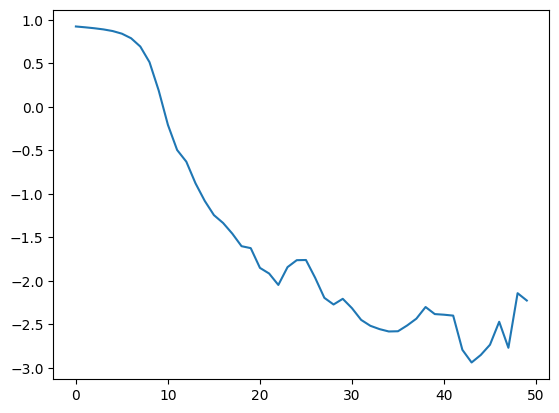

[update L2] post_mean mean=0.0000, std=0.0000, min=-0.0000, max=0.0000
L shape: torch.Size([6000, 1])
F shape: torch.Size([1000, 1])
Y_hat shape: torch.Size([6000, 1000])
Y_noisy shape: torch.Size([6000, 1000])


/var/folders/bs/p8m_n1pj5xq_f1p787_22x6c0000gn/T/ipykernel_13561/2752740099.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L = torch.tensor(y_noisy, dtype=torch.float32).unsqueeze(1)  # shape (n_samples, 1)
/var/folders/bs/p8m_n1pj5xq_f1p787_22x6c0000gn/T/ipykernel_13561/2752740099.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L_true = torch.tensor(y_values, dtype=torch.float32).unsqueeze(1)  # shape (n_samples, 1)


reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 157.5840
[EMDN] Epoch 20/50, Loss: 5.5143
[EMDN] Epoch 30/50, Loss: 5.4234
[EMDN] Epoch 40/50, Loss: 5.3819
[EMDN] Epoch 50/50, Loss: 5.3522


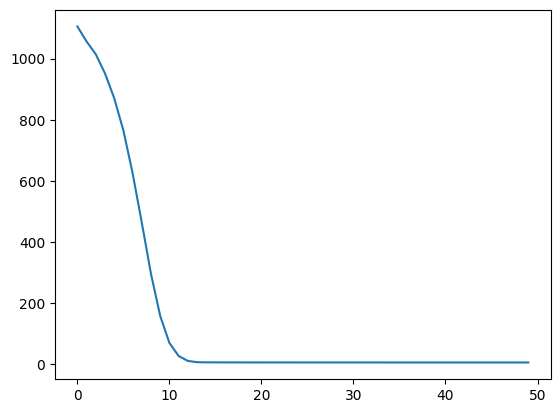

[update L0] post_mean mean=-0.8854, std=51.9902, min=-243.9938, max=224.6854
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: -0.8025
[EMDN] Epoch 20/50, Loss: -1.8937
[EMDN] Epoch 30/50, Loss: -2.1727
[EMDN] Epoch 40/50, Loss: -2.7387
[EMDN] Epoch 50/50, Loss: -2.7410


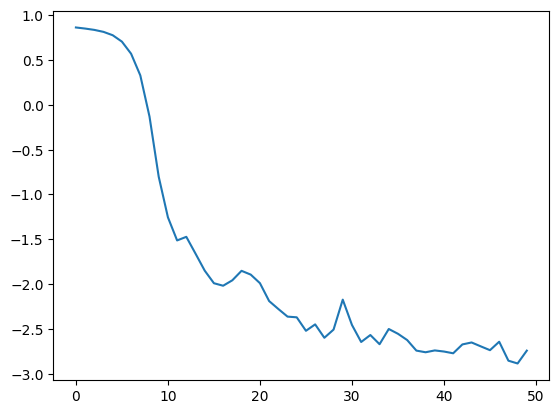

[update L1] post_mean mean=0.0000, std=0.0000, min=-0.0000, max=0.0000
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: -0.3984
[EMDN] Epoch 20/50, Loss: -2.0640
[EMDN] Epoch 30/50, Loss: -2.5459
[EMDN] Epoch 40/50, Loss: -2.3209
[EMDN] Epoch 50/50, Loss: -2.5385


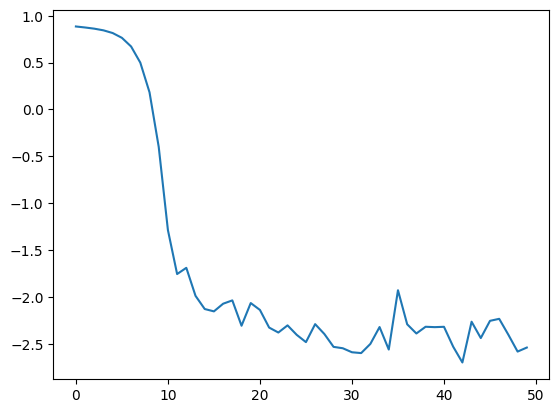

[update L2] post_mean mean=-0.0000, std=0.0000, min=-0.0000, max=0.0000
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 97.8799
[EMDN] Epoch 20/50, Loss: 5.7007
[EMDN] Epoch 30/50, Loss: 5.4635
[EMDN] Epoch 40/50, Loss: 5.3979
[EMDN] Epoch 50/50, Loss: 5.3606


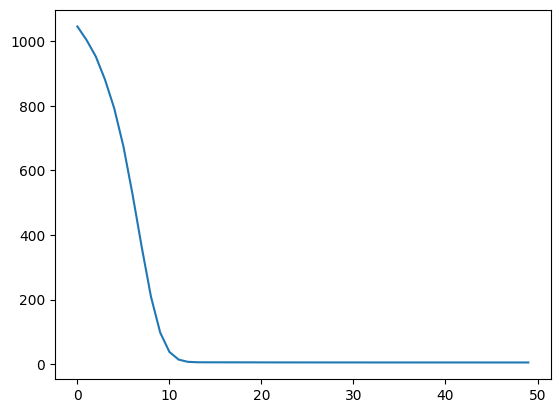

[update L0] post_mean mean=-0.8854, std=51.9902, min=-243.9939, max=224.6855
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: -0.7611
[EMDN] Epoch 20/50, Loss: -2.3051
[EMDN] Epoch 30/50, Loss: -2.4865
[EMDN] Epoch 40/50, Loss: -2.5577
[EMDN] Epoch 50/50, Loss: -2.5380


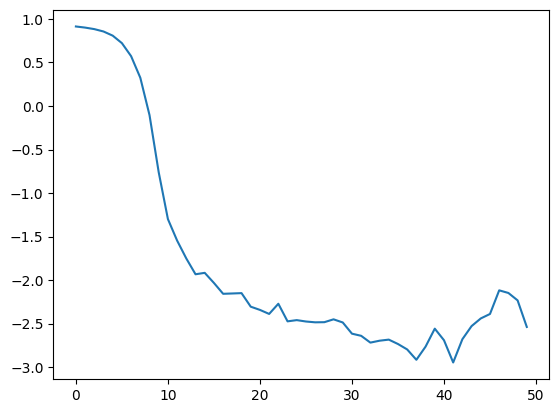

[update L1] post_mean mean=0.0000, std=0.0000, min=-0.0000, max=0.0000
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 0.1751
[EMDN] Epoch 20/50, Loss: -1.7014
[EMDN] Epoch 30/50, Loss: -2.2410
[EMDN] Epoch 40/50, Loss: -2.3266
[EMDN] Epoch 50/50, Loss: -2.7432


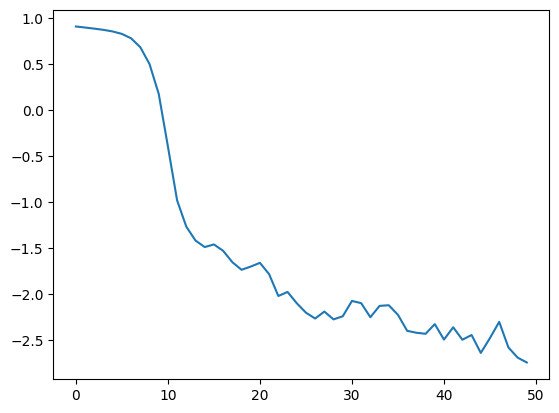

[update L2] post_mean mean=-0.0000, std=0.0000, min=-0.0000, max=0.0000
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 160.1104
[EMDN] Epoch 20/50, Loss: 5.5194
[EMDN] Epoch 30/50, Loss: 5.3539
[EMDN] Epoch 40/50, Loss: 5.2906
[EMDN] Epoch 50/50, Loss: 5.2502


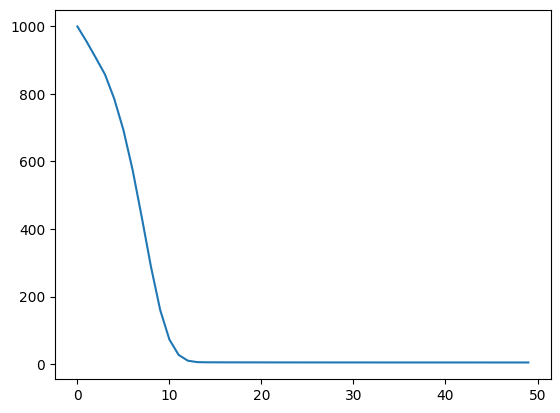

[update L0] post_mean mean=-0.8854, std=51.9902, min=-243.9938, max=224.6855
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: -0.3289
[EMDN] Epoch 20/50, Loss: -1.6510
[EMDN] Epoch 30/50, Loss: -2.4120
[EMDN] Epoch 40/50, Loss: -2.2542
[EMDN] Epoch 50/50, Loss: -2.8072


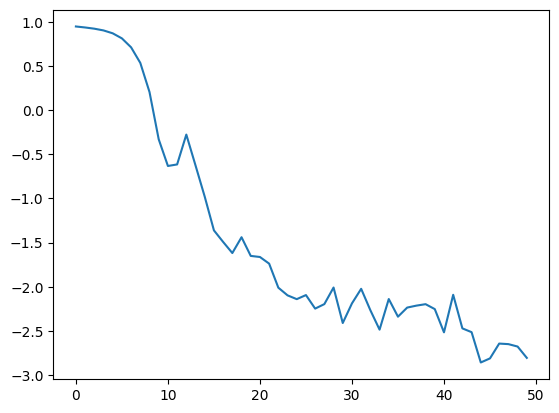

[update L1] post_mean mean=0.0000, std=0.0000, min=-0.0000, max=0.0000
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: -0.1593
[EMDN] Epoch 20/50, Loss: -1.6918
[EMDN] Epoch 30/50, Loss: -2.5580
[EMDN] Epoch 40/50, Loss: -2.8614
[EMDN] Epoch 50/50, Loss: -3.0431


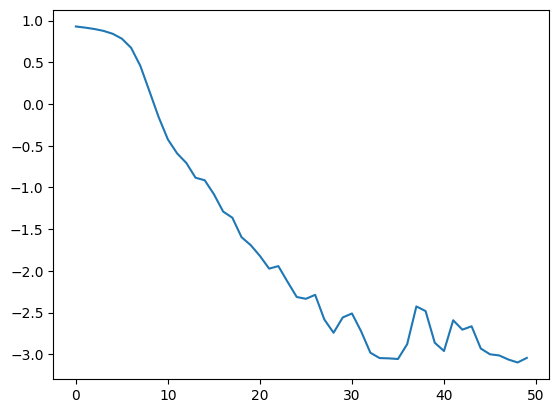

[update L2] post_mean mean=-0.0000, std=0.0000, min=-0.0000, max=0.0000
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 76.4164
[EMDN] Epoch 20/50, Loss: 5.4910
[EMDN] Epoch 30/50, Loss: 5.3456
[EMDN] Epoch 40/50, Loss: 5.2861
[EMDN] Epoch 50/50, Loss: 5.2450


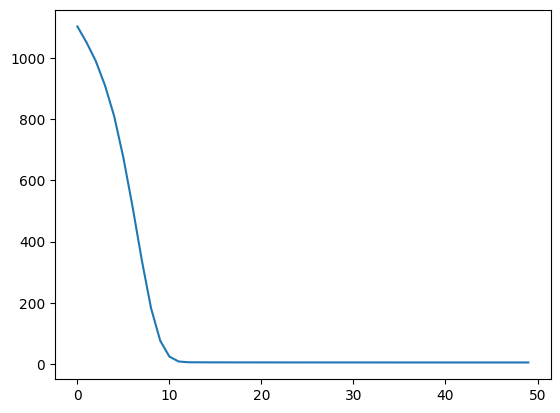

[update L0] post_mean mean=-0.8854, std=51.9902, min=-243.9938, max=224.6854
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: -0.1355
[EMDN] Epoch 20/50, Loss: -1.4335
[EMDN] Epoch 30/50, Loss: -2.0780
[EMDN] Epoch 40/50, Loss: -2.4768
[EMDN] Epoch 50/50, Loss: -2.2758


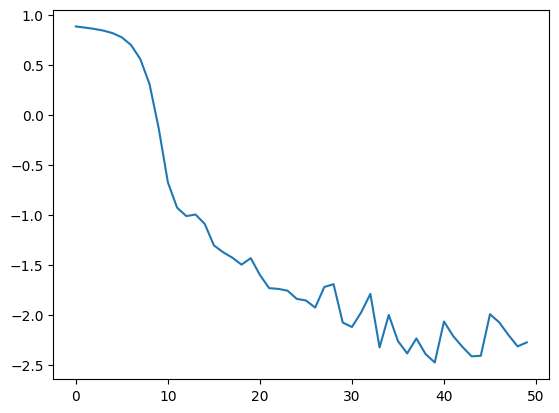

[update L1] post_mean mean=0.0000, std=0.0000, min=-0.0000, max=0.0001
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 0.1073
[EMDN] Epoch 20/50, Loss: -1.8367
[EMDN] Epoch 30/50, Loss: -2.4908
[EMDN] Epoch 40/50, Loss: -2.6884
[EMDN] Epoch 50/50, Loss: -2.9714


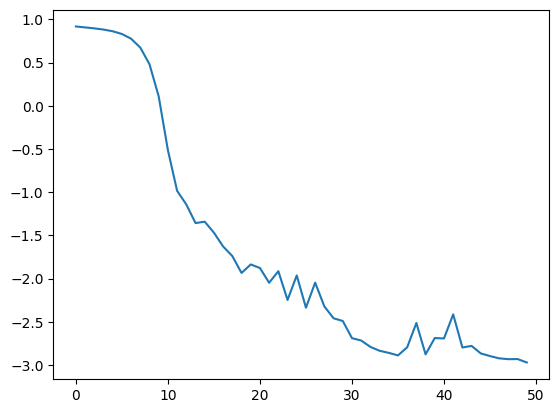

[update L2] post_mean mean=-0.0000, std=0.0000, min=-0.0000, max=0.0000
L shape: torch.Size([7000, 1])
F shape: torch.Size([1000, 1])
Y_hat shape: torch.Size([7000, 1000])
Y_noisy shape: torch.Size([7000, 1000])


/var/folders/bs/p8m_n1pj5xq_f1p787_22x6c0000gn/T/ipykernel_13561/2752740099.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L = torch.tensor(y_noisy, dtype=torch.float32).unsqueeze(1)  # shape (n_samples, 1)
/var/folders/bs/p8m_n1pj5xq_f1p787_22x6c0000gn/T/ipykernel_13561/2752740099.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L_true = torch.tensor(y_values, dtype=torch.float32).unsqueeze(1)  # shape (n_samples, 1)


reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 24.0738
[EMDN] Epoch 20/50, Loss: 5.6763
[EMDN] Epoch 30/50, Loss: 5.4641
[EMDN] Epoch 40/50, Loss: 5.4110
[EMDN] Epoch 50/50, Loss: 5.3790


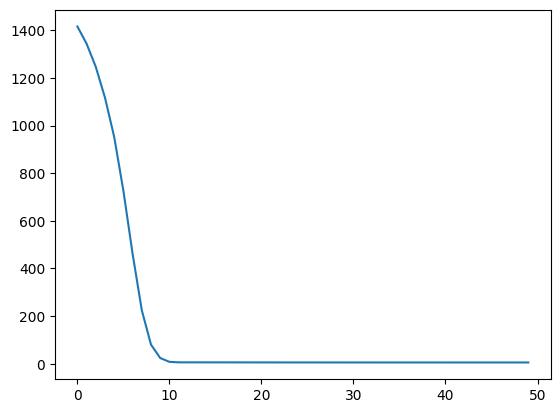

[update L0] post_mean mean=-0.5381, std=54.5164, min=-255.1521, max=234.9608
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: -1.1399
[EMDN] Epoch 20/50, Loss: -2.2392
[EMDN] Epoch 30/50, Loss: -2.5268
[EMDN] Epoch 40/50, Loss: -2.7191
[EMDN] Epoch 50/50, Loss: -2.8122


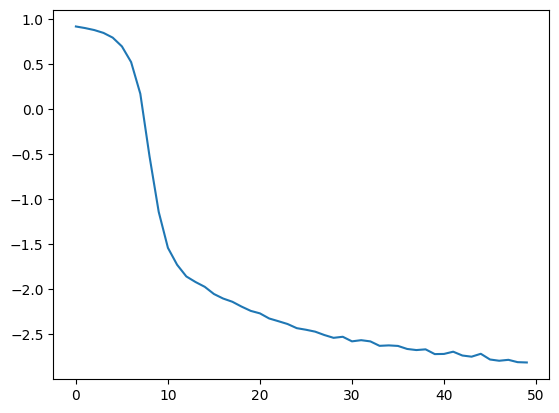

[update L1] post_mean mean=-0.0000, std=0.0000, min=-0.0000, max=0.0000
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: -1.0022
[EMDN] Epoch 20/50, Loss: -2.4296
[EMDN] Epoch 30/50, Loss: -2.5150
[EMDN] Epoch 40/50, Loss: -2.8724
[EMDN] Epoch 50/50, Loss: -3.0308


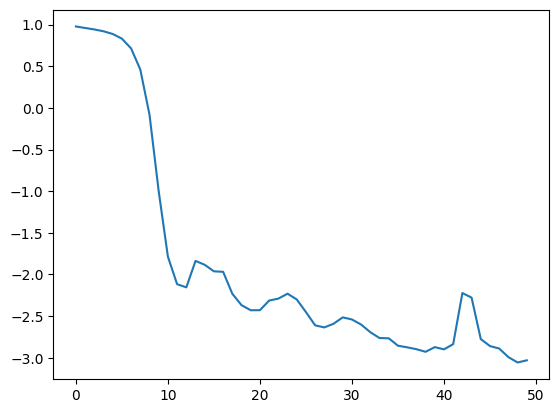

[update L2] post_mean mean=0.0000, std=0.0000, min=-0.0000, max=0.0000
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 7.0603
[EMDN] Epoch 20/50, Loss: 5.5195
[EMDN] Epoch 30/50, Loss: 5.4219
[EMDN] Epoch 40/50, Loss: 5.3772
[EMDN] Epoch 50/50, Loss: 5.3382


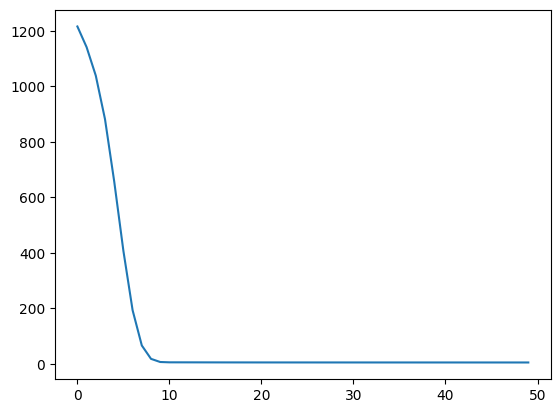

[update L0] post_mean mean=-0.5381, std=54.5164, min=-255.1523, max=234.9610
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: -0.8110
[EMDN] Epoch 20/50, Loss: -1.8015
[EMDN] Epoch 30/50, Loss: -2.4181
[EMDN] Epoch 40/50, Loss: -2.3069
[EMDN] Epoch 50/50, Loss: -2.6686


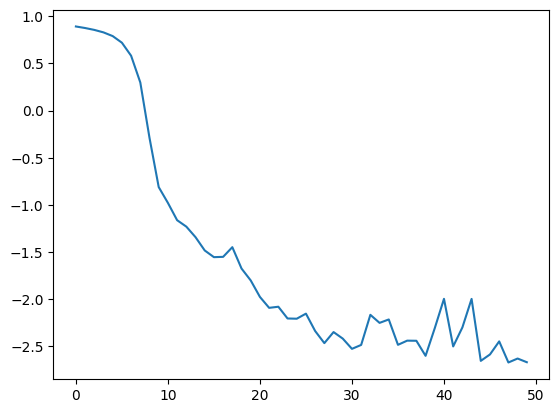

[update L1] post_mean mean=-0.0000, std=0.0000, min=-0.0000, max=0.0000
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: -1.4487
[EMDN] Epoch 20/50, Loss: -1.9599
[EMDN] Epoch 30/50, Loss: -2.2197
[EMDN] Epoch 40/50, Loss: -2.5890
[EMDN] Epoch 50/50, Loss: -2.8839


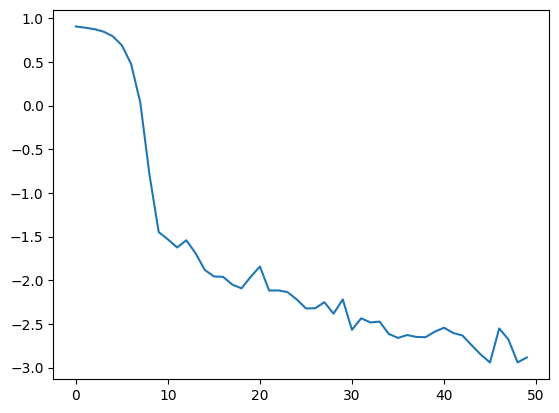

[update L2] post_mean mean=-0.0000, std=0.0000, min=-0.0000, max=0.0000
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 16.4591
[EMDN] Epoch 20/50, Loss: 5.4818
[EMDN] Epoch 30/50, Loss: 5.3741
[EMDN] Epoch 40/50, Loss: 5.3195
[EMDN] Epoch 50/50, Loss: 5.2811


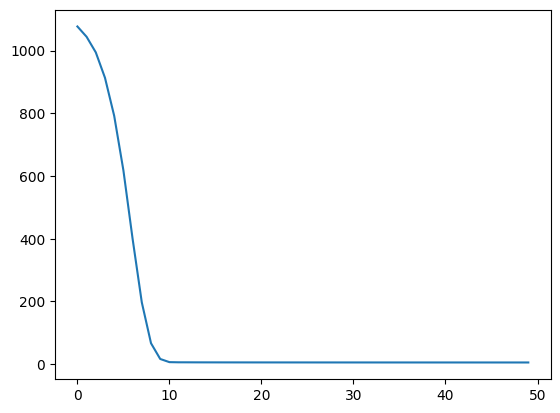

[update L0] post_mean mean=-0.5381, std=54.5164, min=-255.1522, max=234.9608
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: -0.2008
[EMDN] Epoch 20/50, Loss: -1.9936
[EMDN] Epoch 30/50, Loss: -2.5768
[EMDN] Epoch 40/50, Loss: -2.8903
[EMDN] Epoch 50/50, Loss: -3.0197


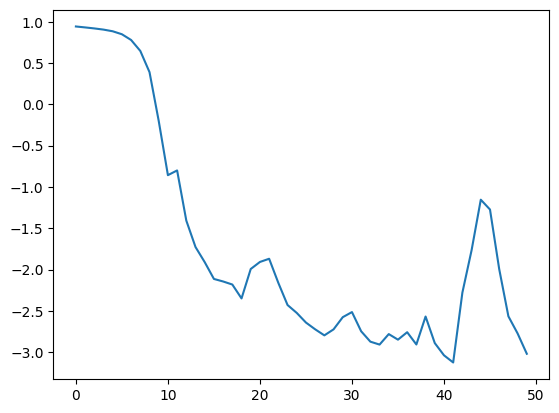

[update L1] post_mean mean=-0.0000, std=0.0000, min=-0.0000, max=0.0000
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: -0.5462
[EMDN] Epoch 20/50, Loss: -2.2210
[EMDN] Epoch 30/50, Loss: -2.6650
[EMDN] Epoch 40/50, Loss: -3.1269
[EMDN] Epoch 50/50, Loss: -2.9426


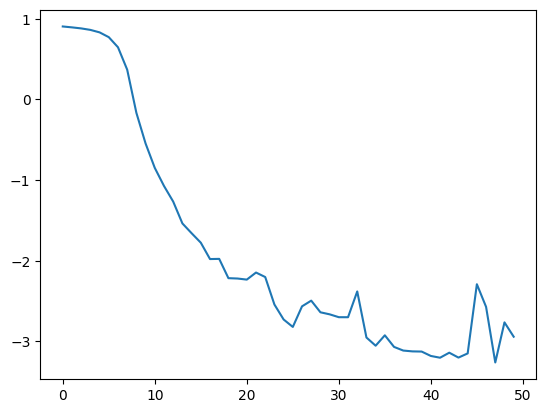

[update L2] post_mean mean=0.0000, std=0.0000, min=-0.0000, max=0.0000
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 22.2271
[EMDN] Epoch 20/50, Loss: 5.4855
[EMDN] Epoch 30/50, Loss: 5.4169
[EMDN] Epoch 40/50, Loss: 5.3614
[EMDN] Epoch 50/50, Loss: 5.3173


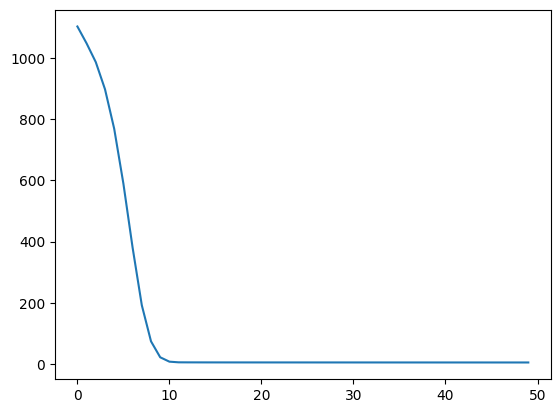

[update L0] post_mean mean=-0.5381, std=54.5164, min=-255.1522, max=234.9609
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: -0.7681
[EMDN] Epoch 20/50, Loss: -1.9017
[EMDN] Epoch 30/50, Loss: -2.5256
[EMDN] Epoch 40/50, Loss: -2.7870
[EMDN] Epoch 50/50, Loss: -2.9331


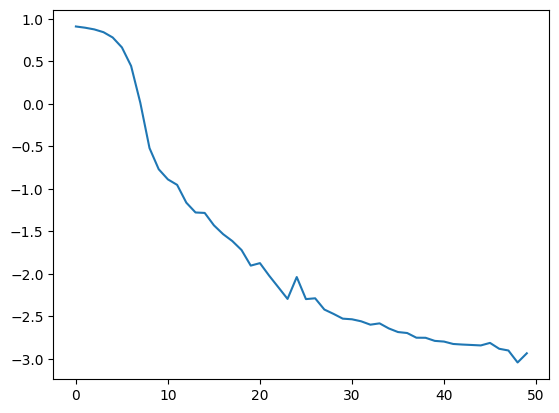

[update L1] post_mean mean=-0.0000, std=0.0000, min=-0.0000, max=0.0000
reg strength: 0.0
[EMDN] Epoch 10/50, Loss: -1.1212
[EMDN] Epoch 20/50, Loss: -2.1860
[EMDN] Epoch 30/50, Loss: -2.8836
[EMDN] Epoch 40/50, Loss: -2.7104
[EMDN] Epoch 50/50, Loss: -2.9602


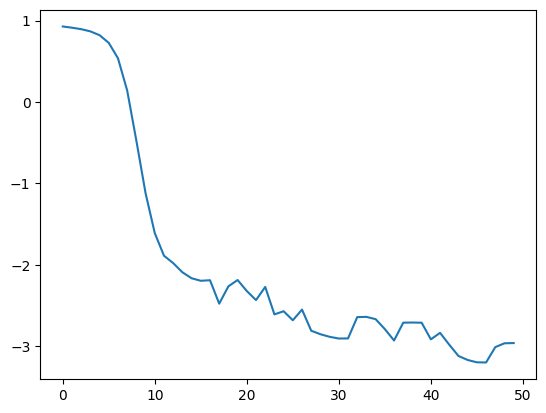

[update L2] post_mean mean=0.0000, std=0.0000, min=-0.0000, max=0.0000
L shape: torch.Size([8000, 1])
F shape: torch.Size([1000, 1])
Y_hat shape: torch.Size([8000, 1000])
Y_noisy shape: torch.Size([8000, 1000])


/var/folders/bs/p8m_n1pj5xq_f1p787_22x6c0000gn/T/ipykernel_13561/2752740099.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L = torch.tensor(y_noisy, dtype=torch.float32).unsqueeze(1)  # shape (n_samples, 1)
/var/folders/bs/p8m_n1pj5xq_f1p787_22x6c0000gn/T/ipykernel_13561/2752740099.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L_true = torch.tensor(y_values, dtype=torch.float32).unsqueeze(1)  # shape (n_samples, 1)


reg strength: 0.0
[EMDN] Epoch 10/50, Loss: 6.0144
[EMDN] Epoch 20/50, Loss: 5.4965
[EMDN] Epoch 30/50, Loss: 5.3967
[EMDN] Epoch 40/50, Loss: 5.3563
[EMDN] Epoch 50/50, Loss: 5.3251


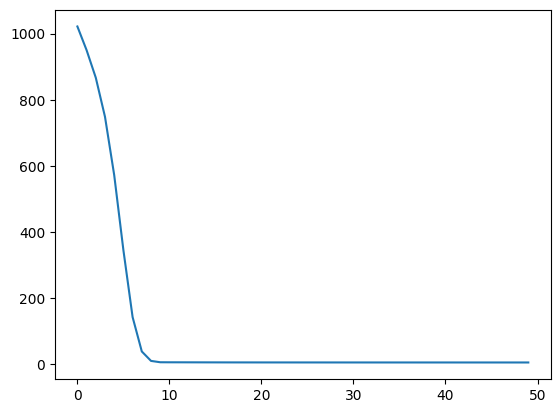

KeyboardInterrupt: 

In [1]:
import torch
from cebmf_torch import cEBMF
from cebmf_torch.torch_main import ModelParams, NoiseParams, CovariateParams


N_to_load = [5000,6000,7000,8000,9000,10000,12500,17500]
loaded_data = torch.load("simulated_dataset.pt")
#vs = []
means = []
meds = []
means2 = []
meds2 = []
for N in N_to_load:
    positions = loaded_data["positions"][:N]
    y_values = loaded_data["y_values"][:N]
    y_noisy = loaded_data["y_noisy"][:N]
    digits = loaded_data["digits"][:N]
    image_label = loaded_data["image_label"][:N]
    label_type = loaded_data["label_type"][:N]
    embedded_images = loaded_data["embedded_images"][:N]
    flattened_images = loaded_data["flattened_images"][:N]
    combined_covariates = torch.cat([embedded_images,positions.unsqueeze(1)], 1)

    combined_covariates_flat = torch.cat([flattened_images,positions.unsqueeze(1)], 1)

    # Suppose we stack noisy observations as a column vector L
    L = torch.tensor(y_noisy, dtype=torch.float32).unsqueeze(1)  # shape (n_samples, 1)
    L_true = torch.tensor(y_values, dtype=torch.float32).unsqueeze(1)  # shape (n_samples, 1)
    
    # Choose number of latent factors (rank)
    K = 1000  
    
    # Generate F as Gaussian random draws
    
    F = torch.randn((K, L.shape[1]))  # shape (K, 1)
    
    # Approximate data matrix
    Y_hat = L @ F.T # shape (n_samples, K)
    
    Y_true = L_true @F.T
    
    Y_noisy = Y_hat #+ torch.randn((Y_hat.shape))
    
    print("L shape:", L.shape)
    print("F shape:", F.shape)
    print("Y_hat shape:", Y_hat.shape)
    print("Y_noisy shape:", Y_noisy.shape)
    model_params = ModelParams(prior_L="emdn", prior_F="norm", K=3)

    covars = CovariateParams(X_l = combined_covariates, X_f = torch.ones(Y_noisy.shape[1]), self_row_cov = True, self_col_cov = False)
    covars2 = CovariateParams(X_l = combined_covariates_flat, X_f = torch.ones(Y_noisy.shape[1]), self_row_cov = True, self_col_cov = False)

    cebmf_model = cEBMF(data=Y_noisy, model=model_params, covariate = covars)    
    cebmf_model2 = cEBMF(data=Y_noisy, model=model_params, covariate = covars2)    
    # Fit
    fit = cebmf_model.fit(maxit=2)
    fit2 = cebmf_model2.fit(maxit=2)

    A_prime = (fit.L @ fit.F.T)
    mse = (Y_true - A_prime)**2
    means.append(torch.mean(mse))
    meds.append(torch.median(mse))

    A_prime2 = (fit2.L @ fit2.F.T)
    mse2 = (Y_true - A_prime2)**2
    means2.append(torch.mean(mse2))
    meds2.append(torch.median(mse2))

Text(0.5, 0, 'mean squared error')

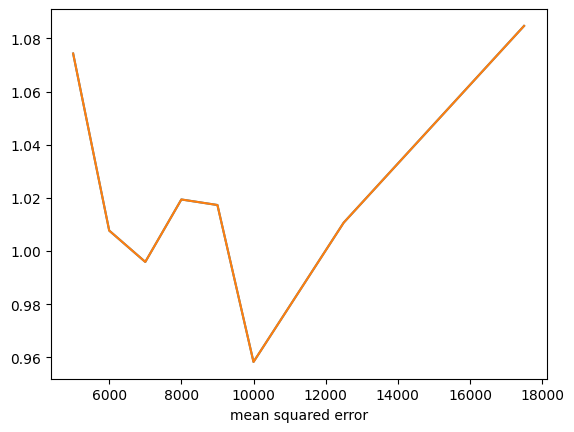

In [43]:
import matplotlib.pyplot as plt
plt.plot([5000,6000,7000,8000,9000,10000,12500,17500], means, label = 'CLIP')
plt.plot([5000,6000,7000,8000,9000,10000,12500,17500], means2, label ='Full Image')

plt.xlabel('mean squared error')

Text(0.5, 0, 'med squared error')

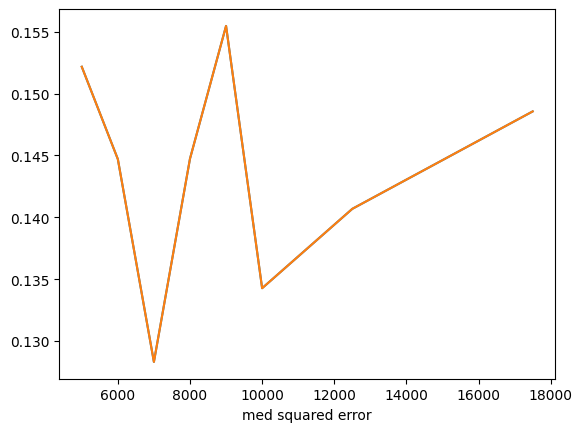

In [40]:
import matplotlib.pyplot as plt
plt.plot([5000,6000,7000,8000,9000,10000,12500,17500], meds, label = 'CLIP')
plt.plot([5000,6000,7000,8000,9000,10000,12500,17500], meds2, label = 'Full Image')
plt.xlabel('med squared error')